# Practical 04 — Distance Measures (Euclidean, Manhattan, Cosine)

## 1. Aim & Objectives

**Aim:** To implement and compare the Euclidean, Manhattan and Cosine distance measures on a sample dataset.

**Objectives:**
1. Take a few sample rows from the Wine dataset as feature vectors.
2. Compute the Euclidean, Manhattan and Cosine distance matrices using Scikit-Learn.
3. Display the three matrices as heatmaps and compare their behaviour.

## 2. Complete Python Code


Sample data used (first 3 columns shown):
   alcohol  malic_acid   ash
0    14.23        1.71  2.43
1    13.20        1.78  2.14
2    13.16        2.36  2.67
3    14.37        1.95  2.50
4    13.24        2.59  2.87

Manual check on Wine 1 and Wine 2
Euclidean : 31.265
Manhattan : 51.06
Cosine    : 0.000291

Euclidean distance matrix:
[[  0.    31.27 122.83 415.25 330.17]
 [ 31.27   0.   135.22 430.25 315.67]
 [122.83 135.22   0.   295.26 450.33]
 [415.25 430.25 295.26   0.   745.04]
 [330.17 315.67 450.33 745.04   0.  ]]

Cosine distance matrix:
[[0.     0.0003 0.0006 0.0009 0.0009]
 [0.0003 0.     0.0001 0.0002 0.0022]
 [0.0006 0.0001 0.     0.0001 0.0029]
 [0.0009 0.0002 0.0001 0.     0.0036]
 [0.0009 0.0022 0.0029 0.0036 0.    ]]


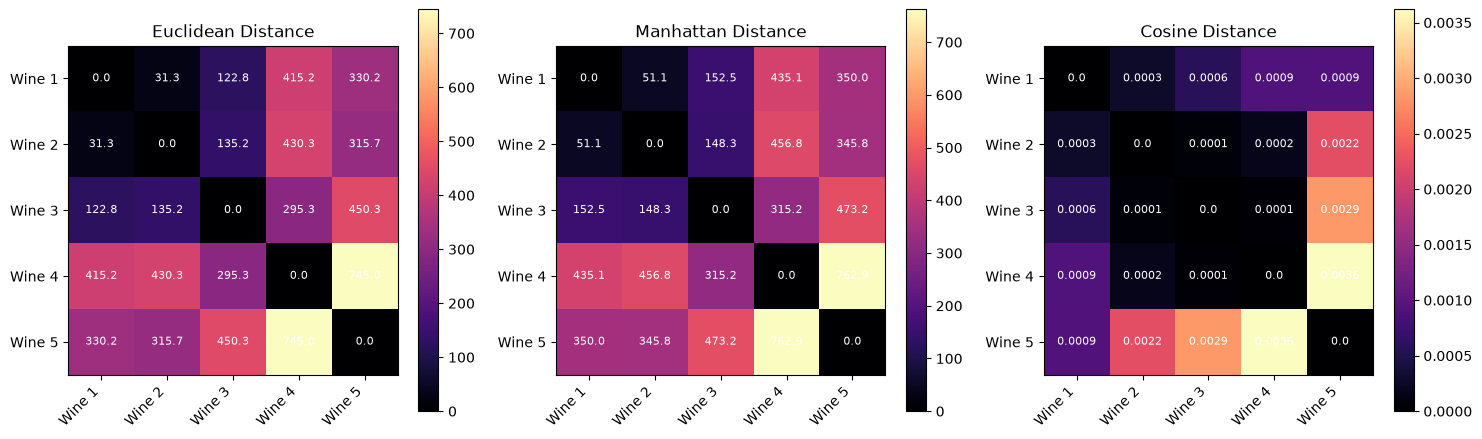

In [1]:
# Practical 04 - Distance Measures (Euclidean, Manhattan, Cosine)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import (
    cosine_distances,
    euclidean_distances,
    manhattan_distances,
)

# Step 1: Load the dataset
CSV = "data/wine.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/04_Distance_Measures/data/wine.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

# Step 2: Take the first 5 wine samples as our vectors
sample = df.drop(columns="cultivar").head(5)
X = sample.to_numpy()
names = ["Wine " + str(i) for i in range(1, 6)]

print("Sample data used (first 3 columns shown):")
print(sample.iloc[:, :3])

# Step 3: Distance between the first two wines, calculated manually
a, b = X[0], X[1]
print("\nManual check on Wine 1 and Wine 2")
print("Euclidean :", round(np.sqrt(np.sum((a - b) ** 2)), 4))
print("Manhattan :", round(np.sum(np.abs(a - b)), 4))
print("Cosine    :", round(1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)), 6))

# Step 4: Full distance matrices using Scikit-Learn
euclid = euclidean_distances(X)
manhat = manhattan_distances(X)
cosine = cosine_distances(X)

print("\nEuclidean distance matrix:")
print(np.round(euclid, 2))
print("\nCosine distance matrix:")
print(np.round(cosine, 4))

# Step 5: Show the three matrices as heatmaps
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, matrix, title, decimals in [
    (ax[0], euclid, "Euclidean Distance", 1),
    (ax[1], manhat, "Manhattan Distance", 1),
    (ax[2], cosine, "Cosine Distance", 4),
]:
    image = axis.imshow(matrix, cmap="magma")
    axis.set_xticks(range(5))
    axis.set_yticks(range(5))
    axis.set_xticklabels(names, rotation=45, ha="right")
    axis.set_yticklabels(names)
    axis.set_title(title)
    for i in range(5):
        for j in range(5):
            axis.text(j, i, round(matrix[i, j], decimals), ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(image, ax=axis)

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.metrics.pairwise import ...` — imports three ready-made distance functions that work on whole matrices at once.
- `df.drop(columns="cultivar")` — removes the class label so only the 13 numeric measurements remain.
- `.head(5)` — takes the first five wine samples; five rows keep the printed matrices small and readable.
- `X = sample.to_numpy()` — converts the table into a NumPy array where each row is one feature vector.
- `a, b = X[0], X[1]` — the first two wine vectors, used for a manual check.
- `np.sqrt(np.sum((a - b) ** 2))` — Euclidean distance: subtract, square, add up, take the square root (straight-line distance).
- `np.sum(np.abs(a - b))` — Manhattan distance: add the absolute differences (city-block distance).
- `1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))` — Cosine distance. `np.dot` is the dot product, `np.linalg.norm` is the length of a vector. Cosine looks only at the angle, not the size.
- `euclidean_distances(X)` — returns a 5×5 matrix with the distance between every pair of rows; the diagonal is 0 because a point is at distance 0 from itself.
- `manhattan_distances(X)` and `cosine_distances(X)` — the same idea for the other two measures.
- `np.round(matrix, 2)` — rounds the matrix before printing so it fits on the screen.
- `axis.imshow(matrix, cmap="magma")` — draws each matrix as a heatmap; dark means small distance, bright means large distance.
- The `for i ... for j` loop with `axis.text(...)` — writes each distance value inside its square.
- `plt.show()` — displays all three heatmaps together.


## 4. Output & Graph Interpretation

The Euclidean and Manhattan heatmaps look similar and are both dominated by the `proline` column, because that feature has values in the hundreds while others are close to 1.

The Cosine heatmap gives very small values for all pairs, because it compares only the direction of the vectors — this is why cosine is preferred for text data and why features should be scaled before using Euclidean or Manhattan distance.
